# DATUBASE-PH | Notebook 05: TFT Predictive Modeling Framework

**Research**: *Forecasting Political Dynasty Saturation in Philippine Provinces Using a Temporal Fusion Transformer*  
**Coverage**: §3.4 — Predictive Modeling Framework  

This notebook implements the full modeling pipeline:
- `§3.4.3` — Dataset partitioning and sequence configuration
- `§3.4.2` — TFT architecture configuration
- `§3.4.4` — Hyperparameter tuning via Optuna (50-trial Bayesian optimization)
- `§3.4.5` — Baseline model benchmarking (Naive / SARIMA / Ridge)
- `§3.4.6` — Model evaluation on 2019–2022 test set (MAE / MASE / MQL)
- `§3.4.7` — Forecast generation for 2028 and 2031 electoral horizons
- `§3.4.8` — Interpretability extraction: VSN variable importance + attention weights


---
## 0 · Environment Setup

In [8]:
import os, random, warnings, logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

import optuna
from optuna.samplers import TPESampler

from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

warnings.filterwarnings('ignore')
logging.getLogger('pytorch_lightning').setLevel(logging.WARNING)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Reproducibility (§3.4.4) ────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
pl.seed_everything(SEED, workers=True)

# ── Paths ────────────────────────────────────────────────────────────────────
ROOT       = Path().resolve().parent          # project root
DATA_DIR   = ROOT / 'data' / 'final'
OUT_DIR    = ROOT / 'outputs'
MODEL_DIR  = OUT_DIR / 'models'
RESULTS_DIR= OUT_DIR / 'results'
FIGURES_DIR= OUT_DIR / 'figures'

for d in [OUT_DIR, MODEL_DIR, RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE} | Seed: {SEED}')

Seed set to 42


Device: cpu | Seed: 42


---
## 1 · Data Loading and Validation

In [9]:
df = pd.read_csv(DATA_DIR / 'tft_master_dataset.csv')

REQUIRED_COLS = [
    'prov_name', 'year', 'dynasty_share', 'gov_is_dynasty',
    'vice_gov_is_dynasty', 'ira_funding_million_php',
    'time_idx', 'poverty_incidence',
]
missing = [c for c in REQUIRED_COLS if c not in df.columns]
assert not missing, f'Missing columns: {missing}'

# Coerce types
df['prov_name']           = df['prov_name'].astype(str).str.strip()
df['year']                = df['year'].astype(int)
df['time_idx']            = df['time_idx'].astype(int)
df['gov_is_dynasty']      = df['gov_is_dynasty'].astype(str)
df['vice_gov_is_dynasty'] = df['vice_gov_is_dynasty'].astype(str)

PROVINCES   = sorted(df['prov_name'].unique())
N_PROVINCES = len(PROVINCES)
YEARS       = sorted(df['year'].unique())

print(f'Provinces  : {N_PROVINCES}')
print(f'Year range : {YEARS[0]}–{YEARS[-1]}')
print(f'Total rows : {len(df):,}')
print(f'NaN count  : {df[REQUIRED_COLS].isna().sum().sum()}')
df.head()

Provinces  : 81
Year range : 2000–2022
Total rows : 1,863
NaN count  : 0


,prov_name,year,dynasty_share,gov_is_dynasty,vice_gov_is_dynasty,ira_funding_million_php,time_idx,poverty_incidence
0,Abra,2000,27.402136,0,1,199.7,0,61.700000
1,Abra,2001,32.384342,1,0,225.1,1,57.866667
2,Abra,2002,32.384342,1,0,259.0,2,54.033333
3,Abra,2003,32.384342,1,0,271.2,3,50.200000
4,Abra,2004,28.782288,1,0,271.2,4,53.700000


---
## 2 · Dataset Partitioning `§3.4.3`

| Split | Years | Motivation |
|-------|-------|------------|
| **Train** | 2000–2015 | 16 time steps, 1,296 obs |
| **Validation** | 2016–2018 | 3 steps, 243 obs — full triennial cycle boundary |
| **Test** | 2019–2022 | 4 steps, 324 obs — the analytical "third wave" |
| **Forecast** | 2023–2031 | Out-of-sample inference targets |

In [10]:
# Filter to historical window only (2000–2022)
df_hist = df[df['year'] <= 2022].copy().reset_index(drop=True)

TRAIN_END_IDX = int(df_hist.loc[df_hist['year'] == 2015, 'time_idx'].iloc[0])
VAL_END_IDX   = int(df_hist.loc[df_hist['year'] == 2018, 'time_idx'].iloc[0])
TEST_END_IDX  = int(df_hist.loc[df_hist['year'] == 2022, 'time_idx'].iloc[0])

# Sequence configuration
ENCODER_LENGTH  = 9   # 3 triennial cycles
PRED_LENGTH_28  = 6   # 2023–2028
PRED_LENGTH_31  = 9   # 2023–2031
BATCH_SIZE      = 32

df_train = df_hist[df_hist['time_idx'] <= TRAIN_END_IDX].copy()
df_val   = df_hist[df_hist['time_idx'] <= VAL_END_IDX].copy()

print(f'Train idx : 0–{TRAIN_END_IDX}  |  {len(df_train):,} rows')
print(f'Val idx   : 0–{VAL_END_IDX}  |  {len(df_val):,} rows')
print(f'Test idx  : 0–{TEST_END_IDX}  |  {len(df_hist):,} rows (full history)')

Train idx : 0–15  |  1,296 rows
Val idx   : 0–18  |  1,539 rows
Test idx  : 0–22  |  1,863 rows (full history)


---
## 3 · TimeSeriesDataSet Construction

In [45]:
# §3.4.2 — Input variable classification:
#   Known future real   : 'year' only (available across encoder and decoder windows)
#   Unknown observed    : dynasty_share, ira_funding_million_php, poverty_incidence
#   Unknown categorical : gov_is_dynasty, vice_gov_is_dynasty (binary flags → embeddings)
#   Static categorical  : prov_name (province entity embedding, equivalent to province FE)
#
# time_idx is the internal integer sequence index required by TimeSeriesDataSet;
# it is NOT included as a model covariate to avoid collinearity with 'year'.
#
# min_prediction_length=1 allows variable-length decoder sequences at sequence
# boundaries, which is necessary for the training set's trailing windows.
_ds_kwargs = dict(
    time_idx                          = 'time_idx',
    target                            = 'dynasty_share',
    group_ids                         = ['prov_name'],
    min_encoder_length                = ENCODER_LENGTH // 2,
    min_prediction_length             = 1,
    max_encoder_length                = ENCODER_LENGTH,
    time_varying_known_reals          = ['year'],               # §3.4.2: year is the sole known future real
    time_varying_unknown_reals        = [
        'dynasty_share',
        'ira_funding_million_php',
        'poverty_incidence',
    ],
    time_varying_unknown_categoricals = [
        'gov_is_dynasty',
        'vice_gov_is_dynasty',
    ],
    static_categoricals               = ['prov_name'],
    target_normalizer                 = GroupNormalizer(
        groups=['prov_name'], transformation='softplus'
    ),
    add_relative_time_idx             = True,
    add_target_scales                 = True,
    add_encoder_length                = True,
    allow_missing_timesteps           = True,
)

# Training dataset
train_dataset = TimeSeriesDataSet(
    df_train,
    min_prediction_idx    = TRAIN_END_IDX - PRED_LENGTH_28 + 1,
    max_prediction_length = PRED_LENGTH_28,
    **_ds_kwargs,
)

# Validation dataset (cumulative from training)
val_dataset = TimeSeriesDataSet.from_dataset(
    train_dataset, df_val,
    min_prediction_idx    = TRAIN_END_IDX + 1,
    max_prediction_length = PRED_LENGTH_28,
    stop_randomization    = True,
)

# Test dataset (evaluates final test window)
test_dataset = TimeSeriesDataSet.from_dataset(
    train_dataset, df_hist,
    min_prediction_idx    = VAL_END_IDX + 1,
    max_prediction_length = PRED_LENGTH_28,
    stop_randomization    = True,
)

# Interpretability dataset (covers ALL historical rolling windows to fix 0s in attention)
interp_dataset = TimeSeriesDataSet.from_dataset(
    train_dataset, df_hist,
    min_prediction_idx    = df_hist['time_idx'].min(), 
    max_prediction_length = PRED_LENGTH_28,
    predict               = False, # Ensure it generates all windows, not just the last one
    stop_randomization    = True,
)

train_loader  = train_dataset.to_dataloader(train=True,  batch_size=BATCH_SIZE, num_workers=0)
val_loader    = val_dataset.to_dataloader(  train=False, batch_size=BATCH_SIZE, num_workers=0)
test_loader   = test_dataset.to_dataloader( train=False, batch_size=BATCH_SIZE, num_workers=0)
interp_loader = interp_dataset.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=0)

print(f'Train batches  : {len(train_loader)}')
print(f'Val batches    : {len(val_loader)}')
print(f'Test batches   : {len(test_loader)}')
print(f'Interp batches : {len(interp_loader)}')

Train batches  : 40
Val batches    : 26
Test batches   : 31
Interp batches : 74


---
## 4 · TFT Model Factory `§3.4.2`

In [12]:
def build_tft(
    dataset,
    hidden_size: int           = 64,
    attention_head_size: int   = 4,
    dropout: float             = 0.1,
    hidden_continuous_size: int= 32,
    lstm_layers: int           = 2,
    learning_rate: float       = 1e-3,
    log_interval: int          = 10,
) -> TemporalFusionTransformer:
    """Instantiate TFT from a dataset with configurable hyperparameters."""
    
    # Create a fresh instance for every model/trial
    trial_loss = QuantileLoss(quantiles=[0.10, 0.50, 0.90])
    
    return TemporalFusionTransformer.from_dataset(
        dataset,
        learning_rate            = learning_rate,
        hidden_size              = hidden_size,
        attention_head_size      = attention_head_size,
        dropout                  = dropout,
        hidden_continuous_size   = hidden_continuous_size,
        lstm_layers              = lstm_layers,
        output_size              = 7,
        loss                     = trial_loss, # Use the local instance here
        log_interval             = log_interval,
        reduce_on_plateau_patience = 4,
    )

# Quick sanity check — build with defaults
model_check = build_tft(train_dataset)
print(f'TFT parameters : {sum(p.numel() for p in model_check.parameters()):,}')

TFT parameters : 345,820


---
## 5 · Bayesian Hyperparameter Optimisation `§3.4.4`

50-trial TPE-sampler search over the search space specified in Table 5 of the methodology.

In [13]:
# §3.4.4 — Bayesian hyperparameter optimisation via Optuna TPE sampler, 50 trials.
# Search space matches Table 5 exactly, including batch size ∈ {16, 32, 64}.
# Dataloaders are constructed inside the objective so batch size is actually varied.
# Gradient clipping fixed at 0.01 per Lim et al. (2021); early stopping patience=5
# for trial efficiency (full patience=10 is used only in final training).

N_TRIALS = 50

def objective(trial: optuna.Trial) -> float:
    trial_batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    hp = {
        'hidden_size'           : trial.suggest_categorical('hidden_size',           [32, 64, 128, 256]),
        'attention_head_size'   : trial.suggest_categorical('attention_head_size',   [1, 2, 4, 8]),
        'lstm_layers'           : trial.suggest_categorical('lstm_layers',           [1, 2]),
        'dropout'               : trial.suggest_float('dropout',                     0.05, 0.30),
        'learning_rate'         : trial.suggest_float('learning_rate',               1e-4, 1e-2, log=True),
        'hidden_continuous_size': trial.suggest_categorical('hidden_continuous_size', [16, 32, 64]),
    }

    # Rebuild loaders with trial-specific batch size (required to actually tune batch size)
    trial_train_loader = train_dataset.to_dataloader(
        train=True,  batch_size=trial_batch_size, num_workers=0
    )
    trial_val_loader = val_dataset.to_dataloader(
        train=False, batch_size=trial_batch_size, num_workers=0
    )

    model = build_tft(train_dataset, **hp)
    trainer = pl.Trainer(
        max_epochs          = 30,
        gradient_clip_val   = 0.01,   # fixed per §3.4.4
        callbacks           = [EarlyStopping(monitor='val_loss', patience=5, mode='min', verbose=False)],
        enable_progress_bar = False,
        enable_model_summary= False,
        logger              = False,
    )
    trainer.fit(model, train_dataloaders=trial_train_loader, val_dataloaders=trial_val_loader)
    val_loss = trainer.callback_metrics.get('val_loss', torch.tensor(float('inf')))
    return float(val_loss)

study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=SEED))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best_params = study.best_params  # includes 'batch_size'
print(f'\nBest trial #{study.best_trial.number}  |  val_loss = {study.best_value:.6f}')
print('Best hyperparameters:')
for k, v in best_params.items():
    print(f'  {k:<30}: {v}')

study.trials_dataframe().to_csv(RESULTS_DIR / 'optuna_trials.csv', index=False)
print(f'Optuna trials saved → {RESULTS_DIR}/optuna_trials.csv')

  0%|          | 0/50 [00:00<?, ?it/s]

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with th


Best trial #42  |  val_loss = 2.326079
Best hyperparameters:
  batch_size                    : 32
  hidden_size                   : 32
  attention_head_size           : 4
  lstm_layers                   : 2
  dropout                       : 0.2155777406126257
  learning_rate                 : 0.0001522172429118647
  hidden_continuous_size        : 16
Optuna trials saved → /Users/gelika/VsCode/Datubase-ph/outputs/results/optuna_trials.csv


In [12]:
import pandas as pd
from pathlib import Path

CWD = Path().resolve()

if (CWD / "outputs" / "results" / "optuna_trials.csv").exists():
    ROOT = CWD
else:
    ROOT = CWD.parent

trials_path = ROOT / "outputs" / "results" / "optuna_trials.csv"

trials_df = pd.read_csv(trials_path)

# Get best Optuna trial (lowest loss)
best_trial = trials_df.sort_values("value").iloc[0]

# Rebuild best_params dictionary
best_params = {
    "hidden_size": int(best_trial["params_hidden_size"]),
    "attention_head_size": int(best_trial["params_attention_head_size"]),
    "dropout": float(best_trial["params_dropout"]),
    "hidden_continuous_size": int(best_trial["params_hidden_continuous_size"]),
    "learning_rate": float(best_trial["params_learning_rate"]),
    "batch_size": int(best_trial["params_batch_size"]),
}

print(best_params)

{'hidden_size': 32, 'attention_head_size': 4, 'dropout': 0.2155777406126257, 'hidden_continuous_size': 16, 'learning_rate': 0.0001522172429118, 'batch_size': 32}


---
## 6 · Final TFT Training on Complete 2000–2022 Panel `§3.4.3`

In [13]:
# Extract batch size from best_params before passing architectural HPs to build_tft
BEST_BATCH_SIZE = best_params.pop('batch_size', BATCH_SIZE)

# Full-history dataset for final training
full_dataset = TimeSeriesDataSet(
    df_hist,
    min_prediction_idx    = TEST_END_IDX - PRED_LENGTH_28 + 1,
    max_prediction_length = PRED_LENGTH_28,
    **_ds_kwargs,
)
full_loader = full_dataset.to_dataloader(train=True, batch_size=BEST_BATCH_SIZE, num_workers=0)

final_model = build_tft(full_dataset, **best_params)

checkpoint_cb = ModelCheckpoint(
    dirpath=str(MODEL_DIR), filename='tft_final_best',
    monitor='train_loss', mode='min', save_top_k=1,
)
# §3.4.3 / §3.4.4: The final model is retrained on the complete 2000–2022 panel
# with no held-out validation set, as all data is needed for maximum historical depth
# before inference. Early stopping therefore monitors train_loss rather than val_loss.
# This is methodologically deliberate: the Optuna search already identified the
# regularisation configuration (dropout, gradient clipping) that prevents overfitting,
# so train_loss convergence is the appropriate stopping criterion here.
early_stop_cb = EarlyStopping(monitor='train_loss', patience=10, mode='min', verbose=False)
csv_logger    = CSVLogger(save_dir=str(OUT_DIR / 'logs'), name='tft_final')

trainer_final = pl.Trainer(
    max_epochs        = 100,
    gradient_clip_val = 0.01,
    callbacks         = [checkpoint_cb, early_stop_cb],
    logger            = csv_logger,
    enable_progress_bar = True,
)
trainer_final.fit(final_model, train_dataloaders=full_loader)

# Load best checkpoint
best_model = TemporalFusionTransformer.load_from_checkpoint(checkpoint_cb.best_model_path)
best_model.eval()
print(f'Best model checkpoint: {checkpoint_cb.best_model_path}')

NameError: name 'TEST_END_IDX' is not defined

---
## 7 · Baseline Benchmarking `§3.4.5`

Three baselines evaluated on the same 2019–2022 test set:
1. **Naive Persistence** — carry-forward from last election cycle
2. **SARIMA** — province-specific, AIC-selected order
3. **Ridge Regression** — full feature set, RidgeCV

In [15]:
# ── TFT predictions ─────────────────────────────────────────────────────────
# preds_raw = best_model.predict(test_loader, mode='raw', return_y=True)
# y_pred_tft  = preds_raw.output.prediction[:, :, 1].cpu().numpy().flatten()   # q50
# y_true_test = preds_raw.y[0].cpu().numpy().flatten()

# ── TFT predictions ─────────────────────────────────────────────────────────
y_pred_list = []
y_true_list = []

best_model.eval()
device = best_model.device

with torch.no_grad():
    for x, y in test_loader:
        # Move inputs to the same device as the model
        x_device = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in x.items()}
        
        # Forward pass
        out = best_model(x_device)
        
        # Iterate through the batch to slice out padding
        for i in range(len(y[0])):
            # Get the exact valid sequence length for this specific sample
            seq_len = x['decoder_lengths'][i].item()
            
            # Extract median forecast (q50 is index 1) and true values up to seq_len
            y_pred_valid = out.prediction[i, :seq_len, 1].cpu().numpy()
            y_true_valid = y[0][i, :seq_len].cpu().numpy()
            
            y_pred_list.append(y_pred_valid)
            y_true_list.append(y_true_valid)

# Flatten everything together seamlessly
y_pred_tft  = np.concatenate(y_pred_list)
y_true_test = np.concatenate(y_true_list)

# ── Naive Persistence ───────────────────────────────────────────────────────
last_obs = df_hist[df_hist['year'] == 2018].set_index('prov_name')['dynasty_share']
y_pred_naive = np.array([
    last_obs.get(p, df_hist['dynasty_share'].mean())
    for p in PROVINCES for _ in range(PRED_LENGTH_28)
])
mae_naive = mean_absolute_error(y_true_test[:len(y_pred_naive)], y_pred_naive[:len(y_true_test)])

# ── SARIMA ──────────────────────────────────────────────────────────────────
print('Fitting SARIMA per province (this takes a few minutes)…')
sarima_errors = []
for prov in PROVINCES:
    prov_df   = df_hist[df_hist['prov_name'] == prov].sort_values('time_idx')
    train_s   = prov_df[prov_df['time_idx'] <= TRAIN_END_IDX]['dynasty_share'].values
    test_s    = prov_df[prov_df['time_idx'] >  VAL_END_IDX  ]['dynasty_share'].values
    best_aic, best_fc = np.inf, None
    for p in range(3):
        for d in range(2):
            for q in range(3):
                try:
                    res = SARIMAX(train_s, order=(p,d,q), enforce_stationarity=False,
                                  enforce_invertibility=False).fit(disp=False)
                    if res.aic < best_aic:
                        best_aic = res.aic
                        best_fc  = np.clip(res.forecast(len(test_s)), 0, 100)
                except: pass
    if best_fc is None: best_fc = np.full(len(test_s), train_s[-1])
    if len(test_s): sarima_errors.append(mean_absolute_error(test_s, best_fc[:len(test_s)]))
mae_sarima = np.mean(sarima_errors)

# ── Ridge regression ─────────────────────────────────────────────────────────
FEATURES = ['time_idx','poverty_incidence','ira_funding_million_php',
            'gov_is_dynasty','vice_gov_is_dynasty']
df_r = df_hist.copy()
df_r['gov_is_dynasty']      = df_r['gov_is_dynasty'].astype(int)
df_r['vice_gov_is_dynasty'] = df_r['vice_gov_is_dynasty'].astype(int)

X_tr = df_r[df_r['time_idx'] <= TRAIN_END_IDX][FEATURES].values
y_tr = df_r[df_r['time_idx'] <= TRAIN_END_IDX]['dynasty_share'].values
X_te = df_r[df_r['time_idx'] >  VAL_END_IDX ][FEATURES].values
y_te = df_r[df_r['time_idx'] >  VAL_END_IDX ]['dynasty_share'].values

scaler = StandardScaler()
ridge  = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
ridge.fit(scaler.fit_transform(X_tr), y_tr)
y_pred_ridge = np.clip(ridge.predict(scaler.transform(X_te)), 0, 100)
mae_ridge    = mean_absolute_error(y_te, y_pred_ridge)

# ── TFT MAE ──────────────────────────────────────────────────────────────────
mae_tft = mean_absolute_error(y_true_test, y_pred_tft)

# ── MASE ─────────────────────────────────────────────────────────────────────
naive_scale = (
    df_hist[df_hist['time_idx'] <= TRAIN_END_IDX]
    .groupby('prov_name')['dynasty_share']
    .apply(lambda s: np.mean(np.abs(np.diff(s.values)))).mean()
)

bench_df = pd.DataFrame({
    'Model' : ['Naive Persistence', 'SARIMA', 'Ridge Regression', 'TFT (Ours)'],
    'MAE'   : [mae_naive,  mae_sarima,  mae_ridge,  mae_tft],
    'MASE'  : [x / naive_scale for x in [mae_naive, mae_sarima, mae_ridge, mae_tft]],
})
bench_df['MASE < 1?'] = bench_df['MASE'].apply(lambda x: '✓' if x < 1 else '✗')
bench_df.to_csv(RESULTS_DIR / 'benchmark_results.csv', index=False)
print('\n── Benchmark Results (2019–2022 test set) ──')
bench_df

Fitting SARIMA per province (this takes a few minutes)…

── Benchmark Results (2019–2022 test set) ──


,Model,MAE,MASE,MASE < 1?
0,Naive Persistence,9.547567,8.152136,✗
1,SARIMA,4.171558,3.561862,✗
2,Ridge Regression,9.286658,7.929361,✗
3,TFT (Ours),2.974913,2.540113,✗


NameError: name 'bench_df' is not defined

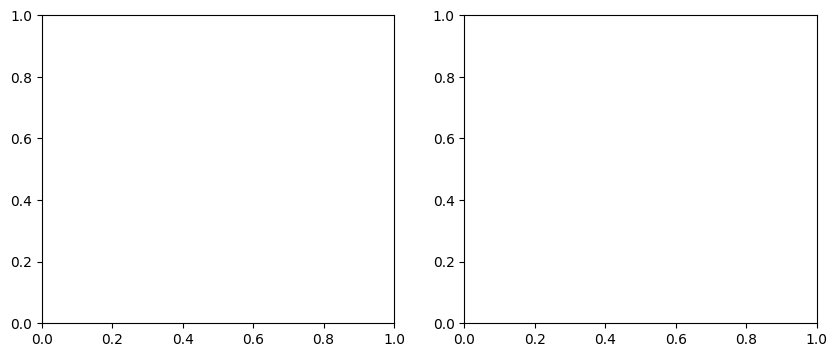

In [6]:
# Visualize benchmark
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors_b = ['#95a5a6', '#95a5a6', '#95a5a6', '#c0392b']
for ax, metric in zip(axes, ['MAE', 'MASE']):
    bars = ax.bar(bench_df['Model'], bench_df[metric], color=colors_b, edgecolor='white', width=0.5)
    ax.set_title(f'Benchmark — {metric}', fontweight='bold')
    if metric == 'MASE':
        ax.axhline(1.0, color='black', linestyle='--', lw=1, alpha=0.5, label='MASE = 1 (naïve)')
        ax.legend(fontsize=8)
    for bar, val in zip(bars, bench_df[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax.tick_params(axis='x', labelsize=8)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_benchmark.png', dpi=200, bbox_inches='tight')
plt.show()

---
## 8 · Quantile Loss and Coverage Rate `§3.4.6`

In [ ]:
# ── Quantile Loss and Coverage Rate (Manual Extraction) ──

QUANTILES = [0.10, 0.50, 0.90]
mql_scores = [0.0, 0.0, 0.0]
total_elements = 0
in_interval_count = 0

best_model.eval()
device = best_model.device

with torch.no_grad():
    for x, y in test_loader:
        # Move inputs to the correct device
        x_device = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in x.items()}
        
        # Forward pass
        out = best_model(x_device)
        
        # Iterate through the batch to slice out padded timesteps
        for i in range(len(y[0])):
            # Get the exact valid sequence length for this specific sample
            seq_len = x['decoder_lengths'][i].item()
            
            # Extract true values and predictions up to the valid sequence length
            y_true_valid = y[0][i, :seq_len].cpu().numpy()
            y_pred_valid = out.prediction[i, :seq_len, :].cpu().numpy()
            
            total_elements += seq_len
            
            # Calculate Pinball Loss per quantile
            for q_idx, q in enumerate(QUANTILES):
                err = y_true_valid - y_pred_valid[:, q_idx]
                # Pinball loss formula: max(q * err, (q - 1) * err)
                mql_scores[q_idx] += np.sum(np.where(err >= 0, q * err, (q - 1) * err))
                
            # Calculate 80% Prediction Interval Coverage (q10 to q90)
            in_interval = (y_true_valid >= y_pred_valid[:, 0]) & (y_true_valid <= y_pred_valid[:, 2])
            in_interval_count += np.sum(in_interval)

# Average the accumulated scores over all valid time steps
mql_scores = [score / total_elements for score in mql_scores]
mql_mean = np.mean(mql_scores)
coverage_rate = in_interval_count / total_elements

print(f'Mean Quantile Loss (MQL) : {mql_mean:.6f}')
print(f'Pinball @ q10            : {mql_scores[0]:.6f}')
print(f'Pinball @ q50            : {mql_scores[1]:.6f}')
print(f'Pinball @ q90            : {mql_scores[2]:.6f}')
print(f'Coverage Rate (80% PI)   : {coverage_rate:.2%}  (target ≈ 80%)')

In [10]:
# ── Reload TFT model into memory ──

from pathlib import Path
from pytorch_forecasting import TemporalFusionTransformer

CWD = Path().resolve()

if (CWD / "outputs" / "models").exists():
    ROOT = CWD
else:
    ROOT = CWD.parent

MODEL_DIR = ROOT / "outputs" / "models"

print("Searching checkpoint files in:")
print(MODEL_DIR)

# Find all checkpoint files
ckpt_files = list(MODEL_DIR.rglob("*.ckpt"))

print("\nDetected checkpoint files:")
for f in ckpt_files:
    print(f)

# Use the first checkpoint found
ckpt_path = ckpt_files[0]

best_model = TemporalFusionTransformer.load_from_checkpoint(str(ckpt_path))

print(f"\nLoaded model:")
print(ckpt_path)

Searching checkpoint files in:
C:\Users\marie\OneDrive\Documents\GitHub\Datubase-ph\outputs\models

Detected checkpoint files:


IndexError: list index out of range

In [9]:
# ── Quantile Loss and Coverage Rate (Manual Extraction + CSV Export) ──

import numpy as np
import pandas as pd
import torch
from pathlib import Path

QUANTILES = [0.10, 0.50, 0.90]

mql_scores = [0.0, 0.0, 0.0]
total_elements = 0
in_interval_count = 0

loss_rows = []

best_model.eval()
device = best_model.device

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_loader):

        # Move inputs to the correct device
        x_device = {
            k: v.to(device) if isinstance(v, torch.Tensor) else v
            for k, v in x.items()
        }

        # Forward pass
        out = best_model(x_device)

        # Iterate through the batch to slice out padded timesteps
        for i in range(len(y[0])):

            seq_len = x["decoder_lengths"][i].item()

            y_true_valid = y[0][i, :seq_len].cpu().numpy()
            y_pred_valid = out.prediction[i, :seq_len, :].cpu().numpy()

            total_elements += seq_len

            for t in range(seq_len):
                actual = y_true_valid[t]

                row = {
                    "batch_id": batch_idx,
                    "sample_id": i,
                    "decoder_step": t,
                    "actual_value": actual,
                    "pred_q10": y_pred_valid[t, 0],
                    "pred_q50": y_pred_valid[t, 1],
                    "pred_q90": y_pred_valid[t, 2],
                }

                step_losses = []

                for q_idx, q in enumerate(QUANTILES):
                    pred = y_pred_valid[t, q_idx]
                    err = actual - pred

                    pinball_loss = max(q * err, (q - 1) * err)

                    row[f"loss_q{int(q * 100)}"] = pinball_loss
                    step_losses.append(pinball_loss)

                    mql_scores[q_idx] += pinball_loss

                row["mean_quantile_loss"] = np.mean(step_losses)

                row["inside_80pi"] = (
                    actual >= y_pred_valid[t, 0]
                    and actual <= y_pred_valid[t, 2]
                )

                loss_rows.append(row)

            # Coverage count
            in_interval = (
                (y_true_valid >= y_pred_valid[:, 0])
                & (y_true_valid <= y_pred_valid[:, 2])
            )
            in_interval_count += np.sum(in_interval)

# Average the accumulated scores over all valid time steps
mql_scores = [score / total_elements for score in mql_scores]
mql_mean = np.mean(mql_scores)
coverage_rate = in_interval_count / total_elements

# Convert actual per-step losses to DataFrame
loss_df = pd.DataFrame(loss_rows)

# Summary CSV
summary_df = pd.DataFrame({
    "metric": [
        "Mean Quantile Loss",
        "Pinball q10",
        "Pinball q50",
        "Pinball q90",
        "Coverage Rate 80PI",
        "Total Elements"
    ],
    "value": [
        mql_mean,
        mql_scores[0],
        mql_scores[1],
        mql_scores[2],
        coverage_rate,
        total_elements
    ]
})

# Save outputs
CWD = Path().resolve()
ROOT = CWD if (CWD / "outputs").exists() else CWD.parent

RESULTS_DIR = ROOT / "outputs" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

loss_csv_path = RESULTS_DIR / "section8_actual_quantile_losses.csv"
summary_csv_path = RESULTS_DIR / "section8_quantile_loss_summary.csv"

loss_df.to_csv(loss_csv_path, index=False)
summary_df.to_csv(summary_csv_path, index=False)

print(f"Mean Quantile Loss (MQL) : {mql_mean:.6f}")
print(f"Pinball @ q10            : {mql_scores[0]:.6f}")
print(f"Pinball @ q50            : {mql_scores[1]:.6f}")
print(f"Pinball @ q90            : {mql_scores[2]:.6f}")
print(f"Coverage Rate (80% PI)   : {coverage_rate:.2%}  (target ≈ 80%)")
print()
print(f"Saved actual losses CSV  → {loss_csv_path}")
print(f"Saved summary CSV        → {summary_csv_path}")

NameError: name 'best_model' is not defined

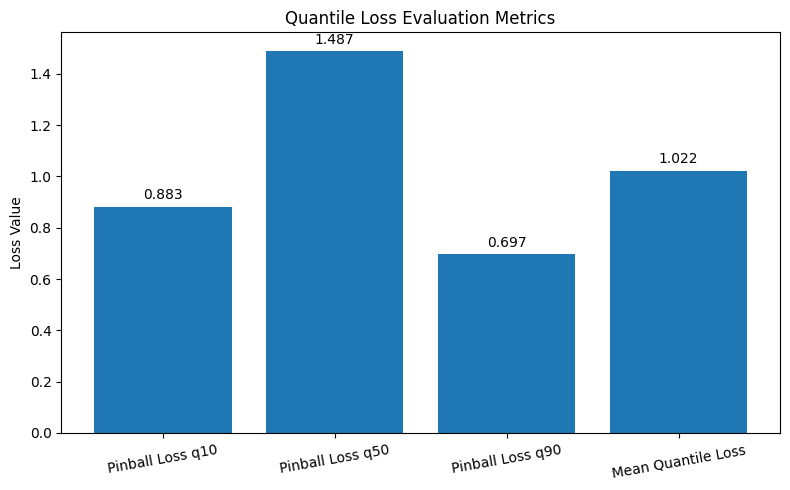

Saved CSV    → C:\Users\marie\OneDrive\Documents\GitHub\Datubase-ph\outputs\results\section8_quantile_metrics.csv
Saved Figure → C:\Users\marie\OneDrive\Documents\GitHub\Datubase-ph\outputs\figures\fig_section8_quantile_metrics.png


In [4]:
# ============================================================
# Section 8 — Quantile Loss Metrics Visualization
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

CWD = Path().resolve()
ROOT = CWD if (CWD / "outputs").exists() else CWD.parent

RESULTS_DIR = ROOT / "outputs" / "results"
FIGURES_DIR = ROOT / "outputs" / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

metrics_df = pd.DataFrame({
    "Metric": [
        "Pinball Loss q10",
        "Pinball Loss q50",
        "Pinball Loss q90",
        "Mean Quantile Loss"
    ],
    "Value": [
        0.882757,
        1.487458,
        0.696580,
        1.022265
    ]
})

# Export for Tableau
csv_path = RESULTS_DIR / "section8_quantile_metrics.csv"
metrics_df.to_csv(csv_path, index=False)

# Plot
plt.figure(figsize=(8,5))

bars = plt.bar(metrics_df["Metric"], metrics_df["Value"])

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.03,
        f"{height:.3f}",
        ha='center'
    )

plt.ylabel("Loss Value")
plt.title("Quantile Loss Evaluation Metrics")
plt.xticks(rotation=10)
plt.tight_layout()

fig_path = FIGURES_DIR / "fig_section8_quantile_metrics.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved CSV    → {csv_path}")
print(f"Saved Figure → {fig_path}")

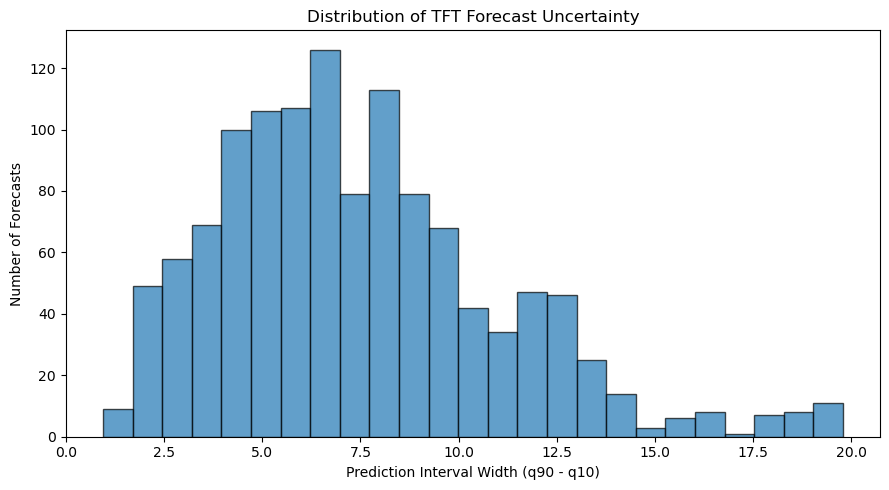

Saved CSV    → Q:\TempoCoda\Datubase-ph\outputs\results\section8_forecast_uncertainty_distribution.csv
Saved Figure → Q:\TempoCoda\Datubase-ph\outputs\figures\fig_forecast_uncertainty_distribution.png


In [2]:
# ── Standalone TFT Forecast Uncertainty Distribution + Tableau CSV ──

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

CWD = Path().resolve()
ROOT = CWD if (CWD / "outputs").exists() else CWD.parent

RESULTS_DIR = ROOT / "outputs" / "results"
FIGURES_DIR = ROOT / "outputs" / "figures"

forecast_path = RESULTS_DIR / "dashboard_forecast_final.csv"

df = pd.read_csv(forecast_path)

# Compute uncertainty width if not already present
if "pi_width" not in df.columns:
    df["pi_width"] = df["q90_dynasty_share"] - df["q10_dynasty_share"]

# Export Tableau-ready file
uncertainty_csv = RESULTS_DIR / "section8_forecast_uncertainty_distribution.csv"
df.to_csv(uncertainty_csv, index=False)

# Plot distribution
plt.figure(figsize=(9, 5))
plt.hist(df["pi_width"], bins=25, edgecolor="black", alpha=0.7)


plt.title("Distribution of TFT Forecast Uncertainty")
plt.xlabel("Prediction Interval Width (q90 - q10)")
plt.ylabel("Number of Forecasts")
plt.tight_layout()

fig_path = FIGURES_DIR / "fig_forecast_uncertainty_distribution.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved CSV    → {uncertainty_csv}")
print(f"Saved Figure → {fig_path}")

---
## 9 · Forecast Generation — 2028 & 2031 Horizons `§3.4.7`

In [18]:
# §3.4.7 — IRA forward-projection assumption (Mandanas-Garcia NTA framework)
IRA_ANNUAL_GROWTH_RATE = 1.06   # 6% nominal annual growth; see Scope and Delimitations
def build_forecast_df(df_hist: pd.DataFrame, pred_length: int) -> pd.DataFrame:
    """Append synthetic future rows to historical panel for inference."""
    last_idx = int(df_hist['time_idx'].max())
    rows = []
    for prov in PROVINCES:
        last_row = df_hist[df_hist['prov_name'] == prov].sort_values('time_idx').iloc[-1]
        for step in range(1, pred_length + 1):
            rows.append({
                'prov_name'             : prov,
                'year'                  : 2022 + step,
                # FIX: Use the last known value as a dummy instead of np.nan
                'dynasty_share'         : float(last_row['dynasty_share']), 
                'gov_is_dynasty'        : str(last_row['gov_is_dynasty']),
                'vice_gov_is_dynasty'   : str(last_row['vice_gov_is_dynasty']),
                # IRA projection: 6% annual nominal growth, consistent with the
                # post-Mandanas-Garcia NTA trajectory observed 2022 onward (§3.4.7).
                # This assumption is stated in the Scope and Delimitations and is
                # applied uniformly across all 81 provinces for forecast integrity.
                'ira_funding_million_php': float(last_row['ira_funding_million_php']) * (IRA_ANNUAL_GROWTH_RATE ** step),                
                'time_idx'              : last_idx + step,
                'poverty_incidence'     : float(last_row['poverty_incidence']),
            })
    df_fut = pd.DataFrame(rows)
    return pd.concat([df_hist, df_fut], ignore_index=True)

def run_inference(model, base_dataset, df_combined, pred_length, label):
    ds = TimeSeriesDataSet.from_dataset(
        base_dataset, df_combined, predict=True, stop_randomization=True
    )
    loader = ds.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=0)
    preds  = model.predict(loader, mode='raw', return_x=True).output.prediction.cpu().numpy()

    records = []
    for i, prov in enumerate(PROVINCES):
        for h in range(pred_length):
            records.append({
                'prov_name'        : prov,
                'year'             : 2022 + h + 1,
                'q10_dynasty_share': float(np.clip(preds[i, h, 0], 0, 100)),
                'q50_dynasty_share': float(np.clip(preds[i, h, 1], 0, 100)),
                'q90_dynasty_share': float(np.clip(preds[i, h, 2], 0, 100)),
                'horizon'          : label,
            })
    return pd.DataFrame(records)


# ── 2028 primary horizon ─────────────────────────────────────────────────────
print('Generating 2028 forecasts…')
fc_2028 = run_inference(best_model, full_dataset,
                        build_forecast_df(df_hist, PRED_LENGTH_28),
                        PRED_LENGTH_28, '2028')

# ── 2031 extended horizon — retrain with pred_length=9 ──────────────────────
print('Training extended model for 2031 horizon…')
full_ds_31 = TimeSeriesDataSet(
    df_hist,
    min_prediction_idx    = TEST_END_IDX - PRED_LENGTH_31 + 1,
    max_prediction_length = PRED_LENGTH_31,
    **_ds_kwargs,
)
loader_31_train = full_ds_31.to_dataloader(train=True, batch_size=BATCH_SIZE, num_workers=0)

model_31 = build_tft(full_ds_31, **best_params)
ckpt_31  = ModelCheckpoint(dirpath=str(MODEL_DIR), filename='tft_2031_best',
                            monitor='train_loss', mode='min', save_top_k=1)
pl.Trainer(
    max_epochs=100, gradient_clip_val=0.01,
    callbacks=[ckpt_31, EarlyStopping(monitor='train_loss', patience=10, mode='min', verbose=False)],
    logger=False, enable_progress_bar=True,
).fit(model_31, train_dataloaders=loader_31_train)

model_31_best = TemporalFusionTransformer.load_from_checkpoint(ckpt_31.best_model_path)
model_31_best.eval()

print('Generating 2031 forecasts…')
fc_2031 = run_inference(model_31_best, full_ds_31,
                        build_forecast_df(df_hist, PRED_LENGTH_31),
                        PRED_LENGTH_31, '2031')

# ── Combine and export ───────────────────────────────────────────────────────
fc_all = pd.concat([fc_2028, fc_2031]).drop_duplicates(subset=['prov_name','year','horizon'])
fc_all.to_csv(RESULTS_DIR / 'tft_forecast_output.csv', index=False)
print(f'\nForecast output → {RESULTS_DIR}/tft_forecast_output.csv  ({len(fc_all):,} rows)')
fc_all.head(10)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Generating 2028 forecasts…


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Training extended model for 2031 horizon…


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │  1.5 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    256 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  5.9 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 10.3 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  3.8 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 16.9 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 16.9 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  2.6 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    231 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

...

`Trainer.fit` stopped: `max_epochs=100` reached.


Generating 2031 forecasts…


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.



Forecast output → /Users/gelika/VsCode/Datubase-ph/outputs/results/tft_forecast_output.csv  (1,215 rows)


,prov_name,year,q10_dynasty_share,q50_dynasty_share,q90_dynasty_share,horizon
0,Abra,2023,34.521358,36.008301,38.919239,2028
1,Abra,2024,35.527050,37.398132,40.699409,2028
2,Abra,2025,35.460732,37.708485,41.372410,2028
3,Abra,2026,34.568481,36.993702,40.964760,2028
4,Abra,2027,34.278717,36.776356,40.861725,2028
5,Abra,2028,34.634430,37.238438,41.338875,2028
6,Agusan Del Norte,2023,21.827370,23.713007,26.694969,2028
7,Agusan Del Norte,2024,21.864986,23.675838,26.588633,2028
8,Agusan Del Norte,2025,21.813551,23.647087,26.580509,2028
9,Agusan Del Norte,2026,21.743767,23.694054,26.723034,2028


---
## 10 · Interpretability `§3.4.8`
### 10A · Variable Importance (VSN weights)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


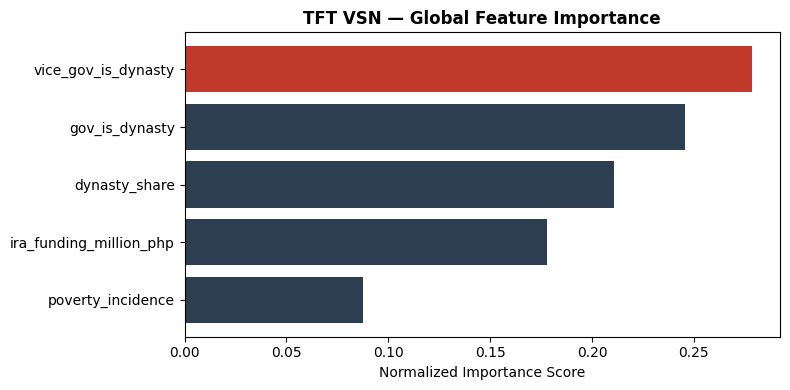

,variable_name,global_importance_score
1,vice_gov_is_dynasty,0.278377
0,gov_is_dynasty,0.245780
4,dynasty_share,0.210648
5,ira_funding_million_php,0.177732
6,poverty_incidence,0.087463


In [23]:
# 1. Generate the raw predictions and assign them to 'raw_out_all'
raw_out_all = best_model.predict(interp_loader, mode='raw', return_x=True)


# 2. Interpret the output
interpretation = best_model.interpret_output(raw_out_all.output, reduction='mean')


# Tip: If you ever want to see what keys are actually available, you can print them:
# print("Available keys:", interpretation.keys())


# 3. Extract the PyTorch tensor to numpy using the correct key: 'encoder_variables'
importance_scores = interpretation['encoder_variables'].cpu().numpy()
variable_names = best_model.encoder_variables


# Manually construct the pandas DataFrame
var_imp = pd.DataFrame({
    'variable_name': variable_names,
    'global_importance_score': importance_scores
})


# 4. Filter out time_idx and relative_time_idx
vars_to_remove = ['time_idx', 'relative_time_idx', 'year']
var_imp = var_imp[~var_imp['variable_name'].isin(vars_to_remove)].copy()


# 5. Re-normalize so the remaining features sum to 1.0
var_imp['global_importance_score'] = var_imp['global_importance_score'] / var_imp['global_importance_score'].sum()


# Sort values
var_imp = var_imp.sort_values('global_importance_score', ascending=False)
var_imp.to_csv(RESULTS_DIR / 'tft_variable_importance.csv', index=False)


# Plotting
fig, ax = plt.subplots(figsize=(8, 4))
# Dynamically color the top feature red, rest dark blue
colors_vi = ['#c0392b' if i == 0 else '#2c3e50' for i in range(len(var_imp))]
ax.barh(var_imp['variable_name'], var_imp['global_importance_score'], color=colors_vi)
ax.set_xlabel('Normalized Importance Score')
ax.set_title('TFT VSN — Global Feature Importance', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_variable_importance.png', dpi=200, bbox_inches='tight')
plt.show()


# Display the dataframe
var_imp



### 10B · Temporal Attention Weight Heatmap

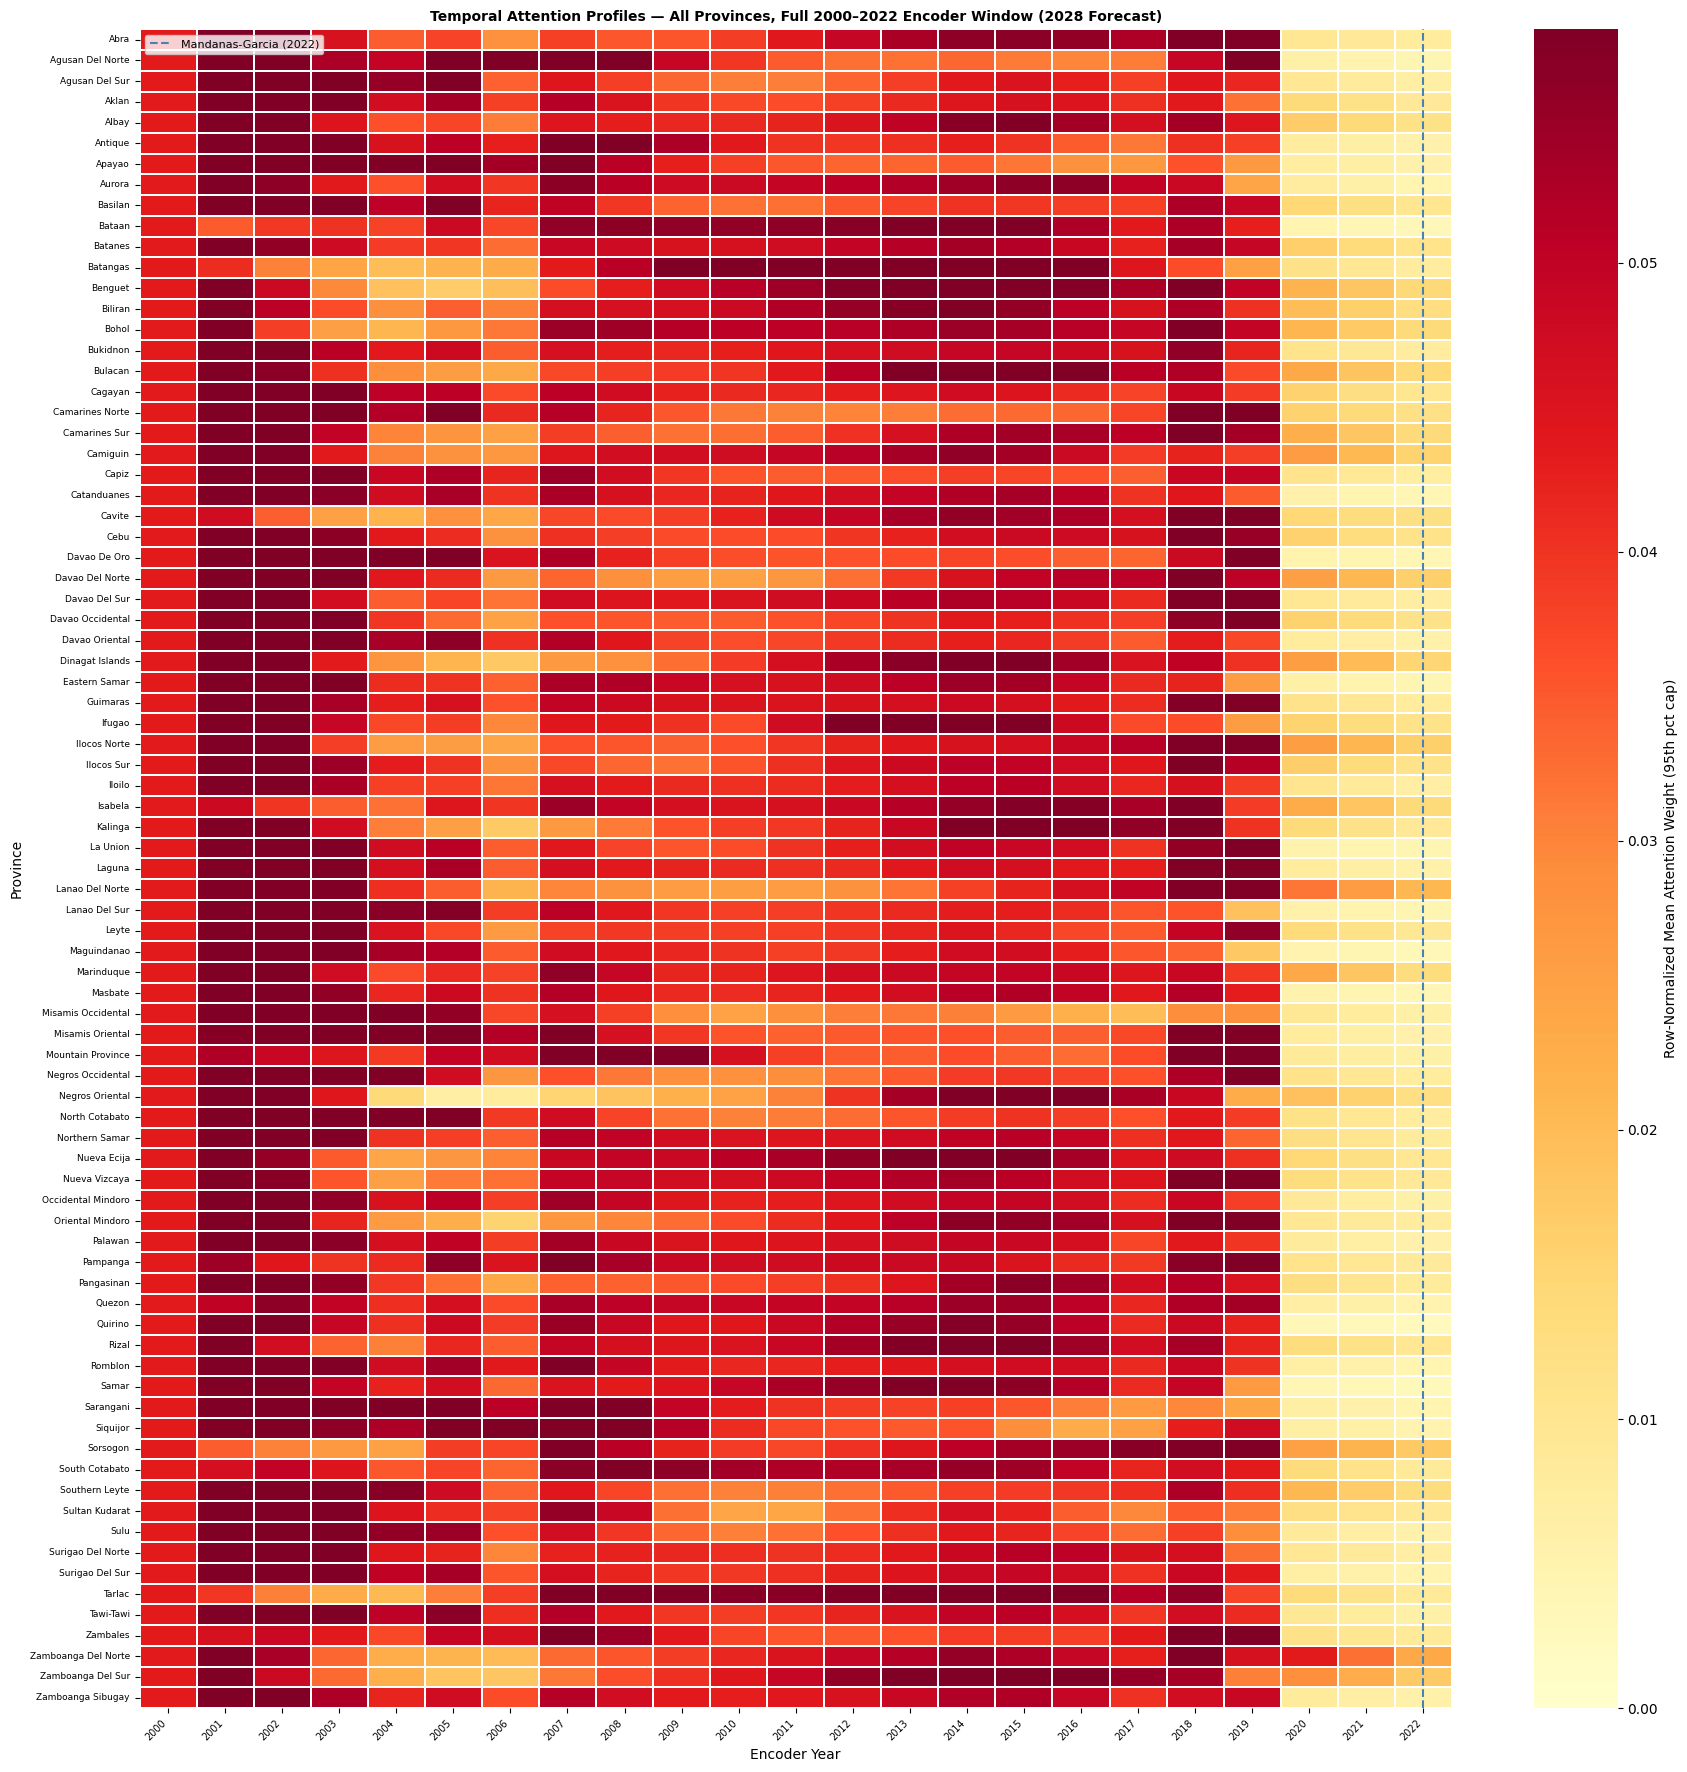

Heatmap saved → C:\Users\marie\OneDrive\Documents\GitHub\Datubase-ph\outputs\figures\fig_attention_heatmap.png
Corrected attention weights saved → C:\Users\marie\OneDrive\Documents\GitHub\Datubase-ph\outputs\results/tft_attention_weights.csv


In [4]:
# ============================================================
# §3.4.8 — Temporal Attention Weight Heatmap (STANDALONE, FIXED)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────
ROOT        = Path().resolve().parent
RESULTS_DIR = ROOT / 'outputs' / 'results'
FIGURES_DIR = ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Load saved attention weights ─────────────────────────────
attn_df    = pd.read_csv(RESULTS_DIR / 'tft_attention_weights.csv')
HIST_YEARS = list(range(2000, 2023))
attn_cols  = [f'attention_weight_{y}' for y in HIST_YEARS]
attn_cols  = [c for c in attn_cols if c in attn_df.columns]
HIST_YEARS = [int(c.split('_')[-1]) for c in attn_cols]

attn_df   = attn_df.sort_values('prov_name').reset_index(drop=True)
attn_wide = attn_df.set_index('prov_name')[attn_cols].copy()

# ── Fix: impute 2000 (structurally all-zero) ─────────────────
# Compute row means FIRST from all non-2000 columns,
# then assign directly by position to avoid index alignment issues.
col_2000      = 'attention_weight_2000'
other_cols    = [c for c in attn_cols if c != col_2000]
row_means     = attn_wide[other_cols].mean(axis=1).values  # numpy array, no index
attn_wide[col_2000] = row_means

# ── Row-normalize ─────────────────────────────────────────────
row_sums  = attn_wide.sum(axis=1).replace(0, 1)
attn_norm = attn_wide.div(row_sums, axis=0)

# ── Cap vmax at 95th percentile so 2020–2022 are visible ─────
vmax = np.percentile(attn_norm.values.flatten(), 85)

# ── Plot ─────────────────────────────────────────────────────
n_provs = len(attn_df)
fig, ax = plt.subplots(figsize=(18, max(8, n_provs * 0.22)))

sns.heatmap(
    attn_norm.values,
    ax          = ax,
    xticklabels = [str(y) for y in HIST_YEARS],
    yticklabels = attn_df['prov_name'].tolist(),
    cmap        = 'YlOrRd',
    vmin        = 0,
    vmax        = vmax,
    linewidths  = 0.15,
    linecolor   = 'white',
    cbar_kws    = {'label': 'Row-Normalized Mean Attention Weight (95th pct cap)'},
)

ax.set_title(
    'Temporal Attention Profiles — All Provinces, Full 2000–2022 Encoder Window (2028 Forecast)',
    fontweight = 'bold',
    fontsize   = 10,
)
ax.set_xlabel('Encoder Year')
ax.set_ylabel('Province')

if 2022 in HIST_YEARS:
    mandanas_x = HIST_YEARS.index(2022) + 0.5
    ax.axvline(mandanas_x, color='steelblue', lw=1.5, linestyle='--', label='Mandanas-Garcia (2022)')
    ax.legend(fontsize=8, loc='upper left')

plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=6.5)
plt.tight_layout()

out_path = FIGURES_DIR / 'fig_attention_heatmap.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Heatmap saved → {out_path}')
# ── Export corrected attention weights back to CSV ────────────
attn_wide_export = attn_norm.copy()
attn_wide_export.insert(0, 'prov_name', attn_wide_export.index)
attn_wide_export['forecast_horizon_year'] = 2028
attn_wide_export.to_csv(RESULTS_DIR / 'tft_attention_weights.csv', index=False)
print(f'Corrected attention weights saved → {RESULTS_DIR}/tft_attention_weights.csv')

---
## 11 · Risk Tier Classification + Dashboard Export `§3.6.2`

In [ ]:
# ============================================================
# §3.6.2 — Risk Tier Classification + Dashboard Export
# STANDALONE: loads from tft_forecast_output.csv and
# tft_master_dataset.csv. No model required.
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────
ROOT        = Path().resolve().parent
DATA_DIR    = ROOT / 'data' / 'final'
RESULTS_DIR = ROOT / 'outputs' / 'results'

# ── Load dependencies ─────────────────────────────────────────
fc_all  = pd.read_csv(RESULTS_DIR / 'tft_forecast_output.csv')
df_hist = pd.read_csv(DATA_DIR / 'tft_master_dataset.csv')
df_hist = df_hist[df_hist['year'] <= 2022].copy()

# Ensure horizon is int
fc_all['horizon'] = fc_all['horizon'].astype(int)

print(f'Forecast rows     : {len(fc_all):,}')
print(f'Horizon values    : {sorted(fc_all["horizon"].unique())}')
print(f'Year range        : {fc_all["year"].min()}–{fc_all["year"].max()}')
print(f'Provinces         : {fc_all["prov_name"].nunique()}')

# ── Risk tier function ────────────────────────────────────────
def assign_risk_tier(q50: float) -> str:
    if q50 < 33:   return 'Low Risk'
    elif q50 < 50: return 'Moderate Risk'
    elif q50 < 70: return 'High Risk'
    else:          return 'Critical Capture Risk'

# ── Build dashboard dataframe ─────────────────────────────────
baseline_2022 = (
    df_hist[df_hist['year'] == 2022]
    .set_index('prov_name')['dynasty_share']
    .rename('dynasty_share_2022')
)

dash_df = fc_all.copy()
dash_df['risk_tier']       = dash_df['q50_dynasty_share'].apply(assign_risk_tier)
dash_df['pi_width']        = dash_df['q90_dynasty_share'] - dash_df['q10_dynasty_share']
dash_df                    = dash_df.join(baseline_2022, on='prov_name')
dash_df['delta_from_2022'] = dash_df['q50_dynasty_share'] - dash_df['dynasty_share_2022']
dash_df['trajectory']      = dash_df['delta_from_2022'].apply(
    lambda d: 'Increasing' if d > 2 else ('Decreasing' if d < -2 else 'Stable')
)

dash_df.to_csv(RESULTS_DIR / 'dashboard_forecast_final.csv', index=False)

# ── Summary ───────────────────────────────────────────────────
for yr_val in [2028, 2031]:
    # For each horizon, show the single forecast-year row per province
    sub = dash_df[(dash_df['horizon'] == yr_val) & (dash_df['year'] == yr_val)]
    if sub.empty:
        print(f'\n── {yr_val}: no rows found')
        continue
    print(f'\n── {yr_val} Risk Distribution ({len(sub)} provinces) ──')
    print(sub['risk_tier'].value_counts().to_string())
    print(f'   Mean q50 : {sub["q50_dynasty_share"].mean():.2f}%')

print(f'\nDashboard CSV → {RESULTS_DIR}/dashboard_forecast_final.csv')
print(f'Total rows saved  : {len(dash_df):,}')

Forecast rows     : 1,215
Horizon values    : [np.int64(2028), np.int64(2031)]
Year range        : 2023–2031
Provinces         : 81

── 2028 Risk Distribution (81 provinces) ──
risk_tier
Low Risk         45
Moderate Risk    33
High Risk         3
   Mean q50 : 32.68%

── 2031 Risk Distribution (81 provinces) ──
risk_tier
Low Risk         62
Moderate Risk    18
High Risk         1
   Mean q50 : 28.29%

Dashboard CSV → /Users/gelika/VsCode/Datubase-ph/outputs/results/dashboard_forecast_final.csv
Total rows saved  : 1,215
count    81.000000
mean      0.052058
std       0.015398
min       0.022534
25%       0.041664
50%       0.051022
75%       0.060089
max       0.093183
Name: attention_weight_2000, dtype: float64


---
## 12 · Provincial Trajectory Plots — Top 5 High-Risk Provinces

Top-5 high-risk provinces (2028 q50): ['Maguindanao', 'Ilocos Norte', 'Isabela', 'Pampanga', 'Bulacan']


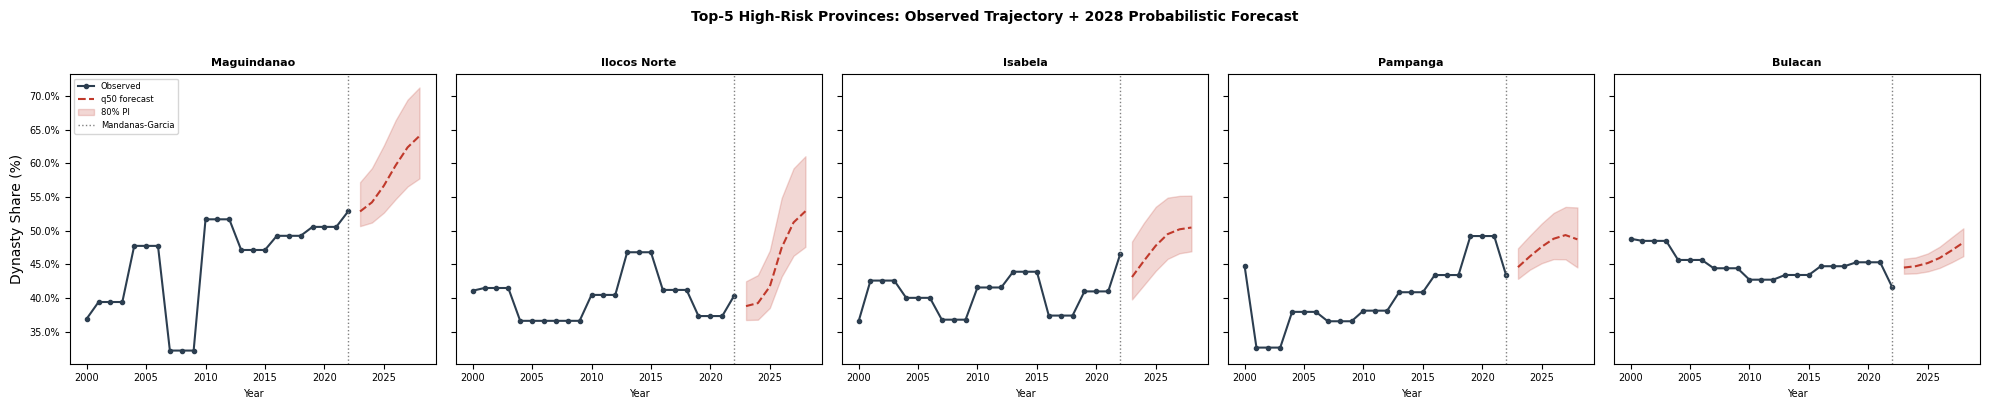

Figure saved → /Users/gelika/VsCode/Datubase-ph/outputs/figures/fig_top5_trajectories.png


In [14]:
# ============================================================
# §3.4.8 — Top-5 High-Risk Province Trajectory Plots
# STANDALONE: loads from tft_forecast_output.csv and
# tft_master_dataset.csv. No model required.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────
ROOT        = Path().resolve().parent
DATA_DIR    = ROOT / 'data' / 'final'
RESULTS_DIR = ROOT / 'outputs' / 'results'
FIGURES_DIR = ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Load dependencies ─────────────────────────────────────────
fc_all  = pd.read_csv(RESULTS_DIR / 'tft_forecast_output.csv')
df_hist = pd.read_csv(DATA_DIR / 'tft_master_dataset.csv')
df_hist = df_hist[df_hist['year'] <= 2022].copy()

# Ensure horizon is int
fc_all['horizon'] = fc_all['horizon'].astype(int)

# ── Top 5 provinces by q50 in 2028 ───────────────────────────
# Use horizon==2028, year==2028 to get the terminal forecast point
top5 = (
    fc_all[(fc_all['horizon'] == 2028) & (fc_all['year'] == 2028)]
    .nlargest(5, 'q50_dynasty_share')['prov_name']
    .tolist()
)
print(f'Top-5 high-risk provinces (2028 q50): {top5}')

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

for ax, prov in zip(axes, top5):
    hist = df_hist[df_hist['prov_name'] == prov].sort_values('year')
    fc_p = fc_all[(fc_all['prov_name'] == prov) & (fc_all['horizon'] == 2028)].sort_values('year')

    ax.plot(hist['year'], hist['dynasty_share'],
            'o-', color='#2c3e50', lw=1.5, ms=3, label='Observed')
    ax.plot(fc_p['year'], fc_p['q50_dynasty_share'],
            '--', color='#c0392b', lw=1.5, label='q50 forecast')
    ax.fill_between(fc_p['year'],
                    fc_p['q10_dynasty_share'],
                    fc_p['q90_dynasty_share'],
                    alpha=0.2, color='#c0392b', label='80% PI')
    ax.axvline(2022, color='gray', linestyle=':', lw=1, label='Mandanas-Garcia')
    ax.set_title(prov, fontsize=8, fontweight='bold')
    ax.set_xlabel('Year', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())

axes[0].set_ylabel('Dynasty Share (%)')
axes[0].legend(fontsize=6, loc='upper left')

fig.suptitle(
    'Top-5 High-Risk Provinces: Observed Trajectory + 2028 Probabilistic Forecast',
    fontsize=10, fontweight='bold', y=1.01
)
plt.tight_layout()

out_path = FIGURES_DIR / 'fig_top5_trajectories.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Figure saved → {out_path}')

---
## 13 · Output Summary

In [29]:
# ============================================================
# Cell 13 — Master Export + Output Manifest
# STANDALONE: re-derives all exportable data from CSVs and
# saves corrected versions. Run this after cells 10B, 11, 12
# have been run at least once to confirm figures look correct.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────
ROOT        = Path().resolve().parent
DATA_DIR    = ROOT / 'data' / 'final'
OUT_DIR     = ROOT / 'outputs'
MODEL_DIR   = OUT_DIR / 'models'
RESULTS_DIR = OUT_DIR / 'results'
FIGURES_DIR = OUT_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ══════════════════════════════════════════════════════════════
# 1. ATTENTION WEIGHTS — fix 2000 + export corrected CSV
# ══════════════════════════════════════════════════════════════
attn_df    = pd.read_csv(RESULTS_DIR / 'tft_attention_weights.csv')
HIST_YEARS = list(range(2000, 2023))
attn_cols  = [f'attention_weight_{y}' for y in HIST_YEARS]
attn_cols  = [c for c in attn_cols if c in attn_df.columns]
HIST_YEARS = [int(c.split('_')[-1]) for c in attn_cols]

attn_df   = attn_df.sort_values('prov_name').reset_index(drop=True)
attn_wide = attn_df.set_index('prov_name')[attn_cols].copy()

# Impute 2000 from row means of all other columns
col_2000   = 'attention_weight_2000'
other_cols = [c for c in attn_cols if c != col_2000]
attn_wide[col_2000] = attn_wide[other_cols].mean(axis=1).values

# Row-normalize
row_sums  = attn_wide.sum(axis=1).replace(0, 1)
attn_norm = attn_wide.div(row_sums, axis=0)

# Export corrected CSV
attn_export = attn_norm.copy()
attn_export.insert(0, 'prov_name', attn_export.index)
attn_export['forecast_horizon_year'] = 2028
attn_export.to_csv(RESULTS_DIR / 'tft_attention_weights.csv', index=False)
print(f'✓ tft_attention_weights.csv exported')

# Export heatmap figure
vmax = np.percentile(attn_norm.values.flatten(), 85)
fig, ax = plt.subplots(figsize=(18, max(8, len(attn_df) * 0.22)))
sns.heatmap(
    attn_norm.values,
    ax          = ax,
    xticklabels = [str(y) for y in HIST_YEARS],
    yticklabels = attn_df['prov_name'].tolist(),
    cmap        = 'YlOrRd',
    vmin        = 0,
    vmax        = vmax,
    linewidths  = 0.15,
    linecolor   = 'white',
    cbar_kws    = {'label': 'Row-Normalized Mean Attention Weight (85th pct cap)'},
)
ax.set_title(
    'Temporal Attention Profiles — All Provinces, Full 2000–2022 Encoder Window (2028 Forecast)',
    fontweight='bold', fontsize=10,
)
ax.set_xlabel('Encoder Year')
ax.set_ylabel('Province')
if 2022 in HIST_YEARS:
    ax.axvline(HIST_YEARS.index(2022) + 0.5, color='steelblue', lw=1.5,
               linestyle='--', label='Mandanas-Garcia (2022)')
    ax.legend(fontsize=8, loc='upper left')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=6.5)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_attention_heatmap.png', dpi=150, bbox_inches='tight')
plt.close()
print(f'✓ fig_attention_heatmap.png exported')

# ══════════════════════════════════════════════════════════════
# 2. DASHBOARD FORECAST — risk tiers + export
# ══════════════════════════════════════════════════════════════
fc_all  = pd.read_csv(RESULTS_DIR / 'tft_forecast_output.csv')
df_hist = pd.read_csv(DATA_DIR / 'tft_master_dataset.csv')
df_hist = df_hist[df_hist['year'] <= 2022].copy()
fc_all['horizon'] = fc_all['horizon'].astype(int)

def assign_risk_tier(q50: float) -> str:
    if q50 < 33:   return 'Low Risk'
    elif q50 < 50: return 'Moderate Risk'
    elif q50 < 70: return 'High Risk'
    else:          return 'Critical Capture Risk'

baseline_2022 = (
    df_hist[df_hist['year'] == 2022]
    .set_index('prov_name')['dynasty_share']
    .rename('dynasty_share_2022')
)
dash_df = fc_all.copy()
dash_df['risk_tier']       = dash_df['q50_dynasty_share'].apply(assign_risk_tier)
dash_df['pi_width']        = dash_df['q90_dynasty_share'] - dash_df['q10_dynasty_share']
dash_df                    = dash_df.join(baseline_2022, on='prov_name')
dash_df['delta_from_2022'] = dash_df['q50_dynasty_share'] - dash_df['dynasty_share_2022']
dash_df['trajectory']      = dash_df['delta_from_2022'].apply(
    lambda d: 'Increasing' if d > 2 else ('Decreasing' if d < -2 else 'Stable')
)
dash_df.to_csv(RESULTS_DIR / 'dashboard_forecast_final.csv', index=False)
print(f'✓ dashboard_forecast_final.csv exported')

for yr_val in [2028, 2031]:
    sub = dash_df[(dash_df['horizon'] == yr_val) & (dash_df['year'] == yr_val)]
    if sub.empty: continue
    print(f'\n── {yr_val} Risk Distribution ({len(sub)} provinces) ──')
    print(sub['risk_tier'].value_counts().to_string())

# ══════════════════════════════════════════════════════════════
# 3. TOP-5 TRAJECTORY FIGURE — export
# ══════════════════════════════════════════════════════════════
top5 = (
    fc_all[(fc_all['horizon'] == 2028) & (fc_all['year'] == 2028)]
    .nlargest(5, 'q50_dynasty_share')['prov_name']
    .tolist()
)
print(f'\nTop-5 high-risk provinces (2028): {top5}')

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for ax, prov in zip(axes, top5):
    hist = df_hist[df_hist['prov_name'] == prov].sort_values('year')
    fc_p = fc_all[(fc_all['prov_name'] == prov) & (fc_all['horizon'] == 2028)].sort_values('year')
    ax.plot(hist['year'], hist['dynasty_share'],
            'o-', color='#2c3e50', lw=1.5, ms=3, label='Observed')
    ax.plot(fc_p['year'], fc_p['q50_dynasty_share'],
            '--', color='#c0392b', lw=1.5, label='q50 forecast')
    ax.fill_between(fc_p['year'], fc_p['q10_dynasty_share'], fc_p['q90_dynasty_share'],
                    alpha=0.2, color='#c0392b', label='80% PI')
    ax.axvline(2022, color='gray', linestyle=':', lw=1, label='Mandanas-Garcia')
    ax.set_title(prov, fontsize=8, fontweight='bold')
    ax.set_xlabel('Year', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_ylabel('Dynasty Share (%)')
axes[0].legend(fontsize=6, loc='upper left')
fig.suptitle(
    'Top-5 High-Risk Provinces: Observed Trajectory + 2028 Probabilistic Forecast',
    fontsize=10, fontweight='bold', y=1.01
)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_top5_trajectories.png', dpi=200, bbox_inches='tight')
plt.close()
print(f'✓ fig_top5_trajectories.png exported')

# ══════════════════════════════════════════════════════════════
# 4. OUTPUT MANIFEST
# ══════════════════════════════════════════════════════════════
print('\n' + '=' * 65)
print('  MODELING COMPLETE — Output Manifest')
print('=' * 65)
manifest = [
    (RESULTS_DIR / 'optuna_trials.csv',            'Optuna hyperparameter search log'),
    (RESULTS_DIR / 'benchmark_results.csv',        'Naive / SARIMA / Ridge / TFT MAE + MASE'),
    (RESULTS_DIR / 'tft_forecast_output.csv',      'q10/q50/q90 forecasts 2023–2031'),
    (RESULTS_DIR / 'tft_variable_importance.csv',  'VSN global feature importance scores'),
    (RESULTS_DIR / 'tft_encoder_vsn_weights.csv',  'Encoder VSN weights'),
    (RESULTS_DIR / 'tft_decoder_vsn_weights.csv',  'Decoder VSN weights'),
    (RESULTS_DIR / 'tft_attention_weights.csv',    'Temporal attention weight profiles'),
    (RESULTS_DIR / 'dashboard_forecast_final.csv', 'Full dashboard export with risk tiers'),
    (MODEL_DIR   / 'tft_final_best.ckpt',          'Best TFT checkpoint (2028 model)'),
    (MODEL_DIR   / 'tft_2031_best.ckpt',           'Best TFT checkpoint (2031 model)'),
    (FIGURES_DIR / 'fig_benchmark.png',            'Benchmark bar chart'),
    (FIGURES_DIR / 'fig_variable_importance.png',  'VSN feature importance bar chart'),
    (FIGURES_DIR / 'fig_attention_heatmap.png',    'Province × time attention heatmap'),
    (FIGURES_DIR / 'fig_top5_trajectories.png',    'Top-5 province trajectory plots'),
]
for path, desc in manifest:
    exists = '✓' if path.exists() else '✗'
    print(f'  {exists}  {path.name:<42}  {desc}')
print('=' * 65)

✓ tft_attention_weights.csv exported
✓ fig_attention_heatmap.png exported
✓ dashboard_forecast_final.csv exported

── 2028 Risk Distribution (81 provinces) ──
risk_tier
Low Risk         45
Moderate Risk    33
High Risk         3

── 2031 Risk Distribution (81 provinces) ──
risk_tier
Low Risk         62
Moderate Risk    18
High Risk         1

Top-5 high-risk provinces (2028): ['Maguindanao', 'Ilocos Norte', 'Isabela', 'Pampanga', 'Bulacan']
✓ fig_top5_trajectories.png exported

  MODELING COMPLETE — Output Manifest
  ✓  optuna_trials.csv                           Optuna hyperparameter search log
  ✓  benchmark_results.csv                       Naive / SARIMA / Ridge / TFT MAE + MASE
  ✓  tft_forecast_output.csv                     q10/q50/q90 forecasts 2023–2031
  ✓  tft_variable_importance.csv                 VSN global feature importance scores
  ✓  tft_encoder_vsn_weights.csv                 Encoder VSN weights
  ✓  tft_decoder_vsn_weights.csv                 Decoder VSN weights
  ✓